# SAT Crédito — Evaluación del Modelo

**Sistema de Alerta Temprana para Mora en Créditos de Consumo**

Este notebook evalúa el desempeño del modelo `GradientBoostingClassifier` entrenado para predecir `atraso_30`, cubriendo:
- Curvas ROC y Precision-Recall
- Matriz de confusión
- Análisis del umbral de decisión
- Importancia de variables
- Calibración del modelo
- Distribución y efectividad de las alertas

In [1]:
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, brier_score_loss
)
from sklearn.calibration import calibration_curve

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

VERDE    = '#2ECC71'
AMARILLO = '#F39C12'
ROJO     = '#E74C3C'
AZUL     = '#2980B9'
MORADO   = '#8E44AD'

In [2]:
# ── Carga de datos y modelo ─────────────────────────────────────────────────
features = pd.read_csv('../data/processed/features.csv')
alertas  = pd.read_csv('../data/processed/alertas_sat.csv')
fi_df    = pd.read_csv('../data/processed/feature_importance.csv')

with open('../src/modelo/modelo_sat.pkl', 'rb') as f:
    pipeline = pickle.load(f)

with open('../src/modelo/metricas.json') as f:
    metricas = json.load(f)

print('Modelo cargado:', metricas['modelo'])
print('Target:        ', metricas['target'])
print(f'AUC-ROC test:  {metricas["auc_roc_test"]:.4f}')

Modelo cargado: GradientBoostingClassifier
Target:         atraso_30
AUC-ROC test:  0.9735


In [3]:
# Reproducir el mismo split 80/20 que se usó en el entrenamiento
TARGET = 'atraso_30'
DROP   = ['atraso_30', 'atraso_60', 'atraso_90',
          'id_solicitud', 'periodo_desembolso', 'nombre_departamento_particular']
FEATURE_COLS = [c for c in features.columns if c not in DROP]

X = features[FEATURE_COLS]
y = features[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_prob  = pipeline.predict_proba(X_test)[:, 1]
y_pred  = (y_prob >= metricas['umbral_optimo_f1']).astype(int)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Prevalencia en test: {y_test.mean()*100:.1f}%')

Train: 308,713  |  Test: 77,179
Prevalencia en test: 29.0%


---
## 1. Métricas Globales

In [4]:
roc_auc  = metricas['auc_roc_test']
avg_prec = metricas['avg_precision']
brier    = brier_score_loss(y_test, y_prob)

resumen = pd.DataFrame([
    {'Métrica': 'AUC-ROC (test)',          'Valor': f"{metricas['auc_roc_test']:.4f}",  'Referencia': '> 0.85 excelente'},
    {'Métrica': 'AUC-ROC (train)',         'Valor': f"{metricas['auc_roc_train']:.4f}", 'Referencia': 'brecha < 0.05 = sin sobreajuste'},
    {'Métrica': 'Average Precision',       'Valor': f"{metricas['avg_precision']:.4f}", 'Referencia': '> 0.80 muy bueno'},
    {'Métrica': 'F1 (clase mora)',         'Valor': f"{metricas['f1_class1']:.4f}",     'Referencia': '> 0.75 adecuado'},
    {'Métrica': 'Precision (clase mora)',  'Valor': f"{metricas['precision_class1']:.4f}", 'Referencia': 'alertas sin ruido'},
    {'Métrica': 'Recall (clase mora)',     'Valor': f"{metricas['recall_class1']:.4f}",  'Referencia': 'cobertura de defaults'},
    {'Métrica': 'CV AUC (5-fold)',         'Valor': f"{metricas['cv_auc_mean']:.4f} ± {metricas['cv_auc_std']:.4f}", 'Referencia': 'estabilidad'},
    {'Métrica': 'Brier Score',             'Valor': f"{brier:.4f}",                     'Referencia': '< 0.10 buena calibración'},
    {'Métrica': 'Brecha train-test AUC',   'Valor': f"{metricas['overfit_gap']:.4f}",   'Referencia': '< 0.05 sin sobreajuste'},
])

resumen.style.set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#2980B9'), ('color', 'white')]}]
).hide(axis='index')

Métrica,Valor,Referencia
AUC-ROC (test),0.9735,> 0.85 excelente
AUC-ROC (train),0.9745,brecha < 0.05 = sin sobreajuste
Average Precision,0.9480,> 0.80 muy bueno
F1 (clase mora),0.8654,> 0.75 adecuado
Precision (clase mora),0.8799,alertas sin ruido
Recall (clase mora),0.8513,cobertura de defaults
CV AUC (5-fold),0.9737 ± 0.0003,estabilidad
Brier Score,0.0560,< 0.10 buena calibración
Brecha train-test AUC,0.0010,< 0.05 sin sobreajuste


---
## 2. Curvas ROC y Precision-Recall

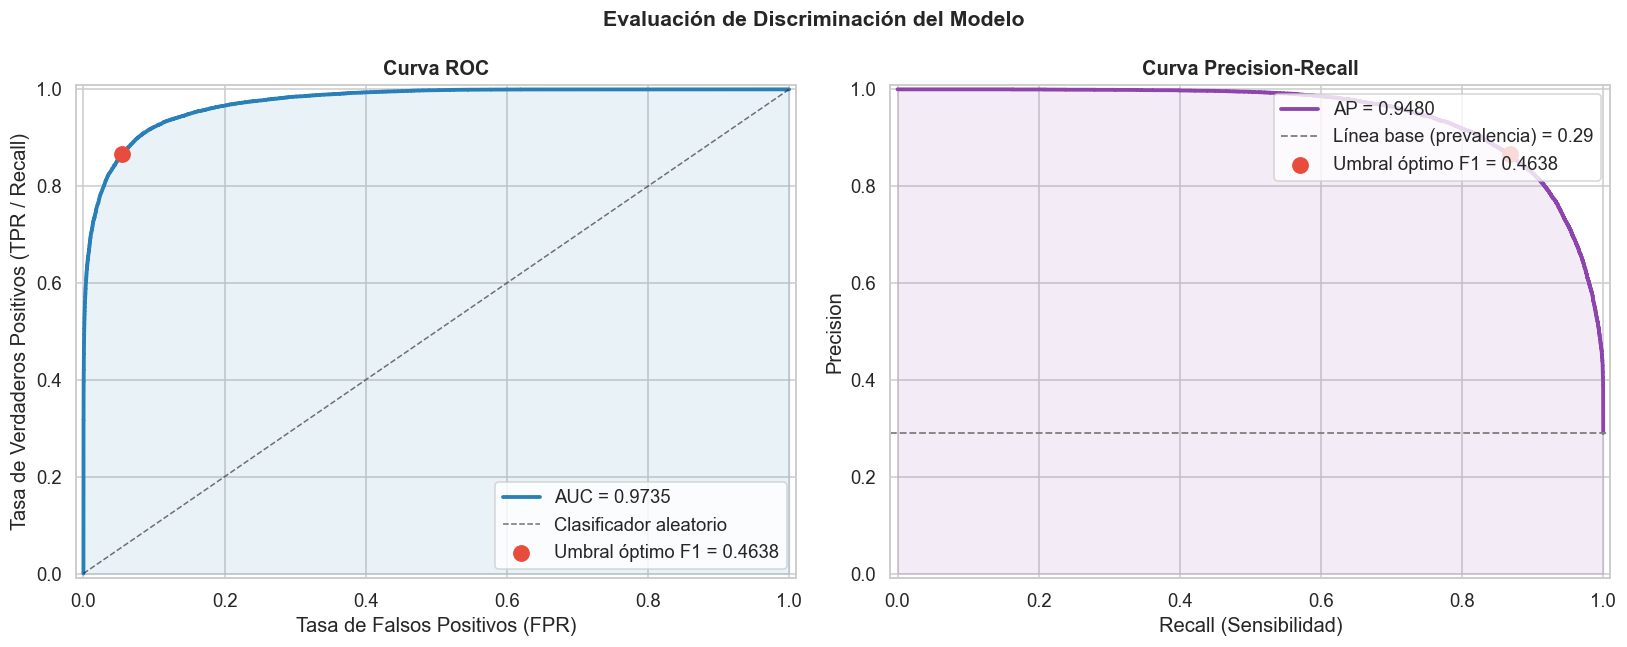

In [5]:
# Curvas ROC y PR
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc_calc = auc(fpr, tpr)

prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test, y_prob)
ap_calc = average_precision_score(y_test, y_prob)

# Punto del umbral óptimo en ROC
umbral_f1 = metricas['umbral_optimo_f1']
idx_opt   = np.argmin(np.abs(thresholds_roc - umbral_f1))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# — ROC —
axes[0].plot(fpr, tpr, color=AZUL, linewidth=2.5, label=f'AUC = {roc_auc_calc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Clasificador aleatorio')
axes[0].scatter(fpr[idx_opt], tpr[idx_opt], color=ROJO, s=100, zorder=5,
                label=f'Umbral óptimo F1 = {umbral_f1:.4f}')
# Sombrear el área
axes[0].fill_between(fpr, tpr, alpha=0.1, color=AZUL)
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.01])

# — Precision-Recall —
axes[1].plot(rec_curve, prec_curve, color=MORADO, linewidth=2.5, label=f'AP = {ap_calc:.4f}')
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1.2,
                label=f'Línea base (prevalencia) = {baseline:.2f}')
# Umbral óptimo en PR
idx_pr = np.argmin(np.abs(thresholds_pr - umbral_f1))
axes[1].scatter(rec_curve[idx_pr], prec_curve[idx_pr], color=ROJO, s=100, zorder=5,
                label=f'Umbral óptimo F1 = {umbral_f1:.4f}')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.1, color=MORADO)
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].set_xlim([-0.01, 1.01])
axes[1].set_ylim([-0.01, 1.01])

plt.suptitle('Evaluación de Discriminación del Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Matriz de Confusión

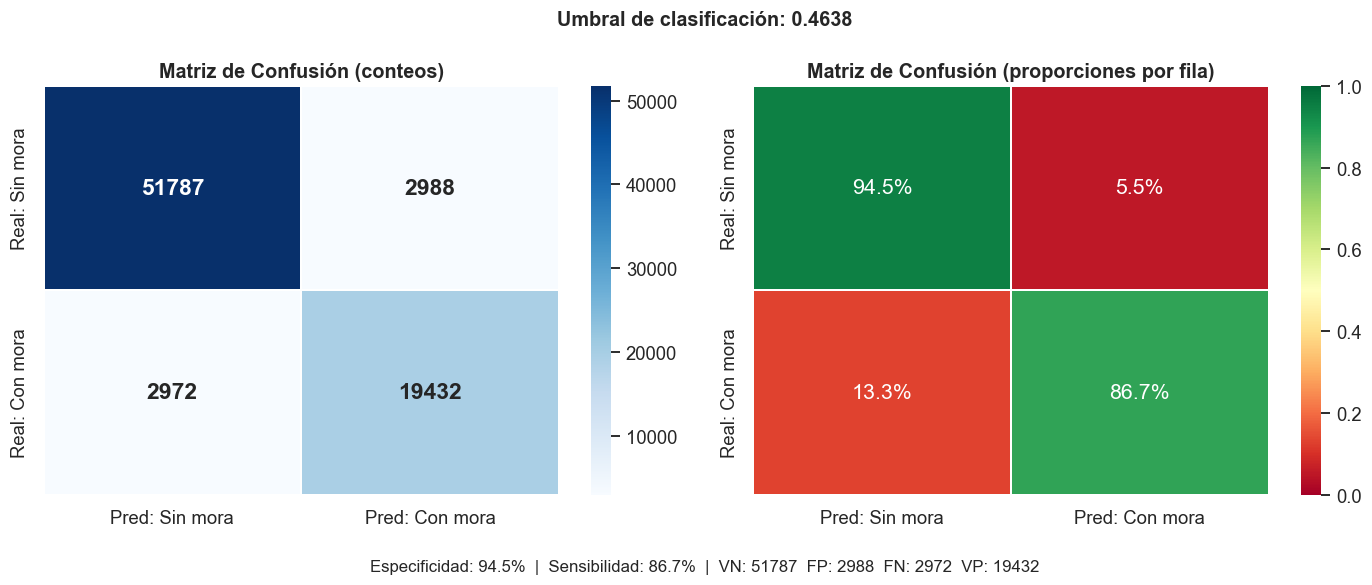

In [6]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Sin mora', 'Pred: Con mora'],
            yticklabels=['Real: Sin mora', 'Real: Con mora'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 15, 'weight': 'bold'}, ax=axes[0])
axes[0].set_title('Matriz de Confusión (conteos)', fontweight='bold')

# Proporciones
annot_norm = np.array([[f'{v:.1%}' for v in row] for row in cm_norm])
sns.heatmap(cm_norm, annot=annot_norm, fmt='', cmap='RdYlGn',
            xticklabels=['Pred: Sin mora', 'Pred: Con mora'],
            yticklabels=['Real: Sin mora', 'Real: Con mora'],
            linewidths=1, linecolor='white',
            vmin=0, vmax=1,
            annot_kws={'size': 14}, ax=axes[1])
axes[1].set_title('Matriz de Confusión (proporciones por fila)', fontweight='bold')

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

fig.text(0.5, -0.04,
         f'Especificidad: {specificity:.1%}  |  Sensibilidad: {sensitivity:.1%}  |  '
         f'VN: {tn}  FP: {fp}  FN: {fn}  VP: {tp}',
         ha='center', fontsize=11)

plt.suptitle(f'Umbral de clasificación: {umbral_f1:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Análisis del Umbral de Decisión

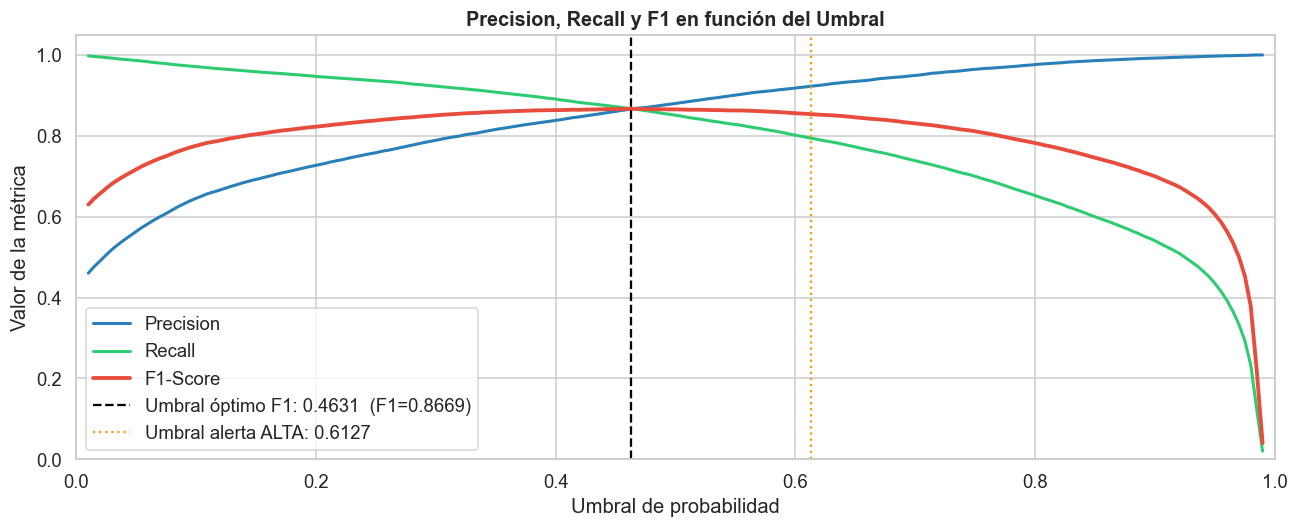

In [7]:
# Precision, Recall y F1 en función del umbral
thresholds_eval = np.linspace(0.01, 0.99, 200)
precisions, recalls, f1s = [], [], []

for t in thresholds_eval:
    y_hat = (y_prob >= t).astype(int)
    tp = ((y_hat == 1) & (y_test == 1)).sum()
    fp = ((y_hat == 1) & (y_test == 0)).sum()
    fn = ((y_hat == 0) & (y_test == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

idx_best = np.argmax(f1s)
t_best   = thresholds_eval[idx_best]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_eval, precisions, color=AZUL,   linewidth=2, label='Precision')
ax.plot(thresholds_eval, recalls,    color=VERDE,  linewidth=2, label='Recall')
ax.plot(thresholds_eval, f1s,        color=ROJO,   linewidth=2.5, label='F1-Score')

ax.axvline(t_best, color='black', linestyle='--', linewidth=1.5,
           label=f'Umbral óptimo F1: {t_best:.4f}  (F1={max(f1s):.4f})')
ax.axvline(metricas['umbral_alerta_alta'], color=AMARILLO, linestyle=':',
           linewidth=1.5, label=f'Umbral alerta ALTA: {metricas["umbral_alerta_alta"]:.4f}')

ax.set_xlabel('Umbral de probabilidad')
ax.set_ylabel('Valor de la métrica')
ax.set_title('Precision, Recall y F1 en función del Umbral', fontweight='bold')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

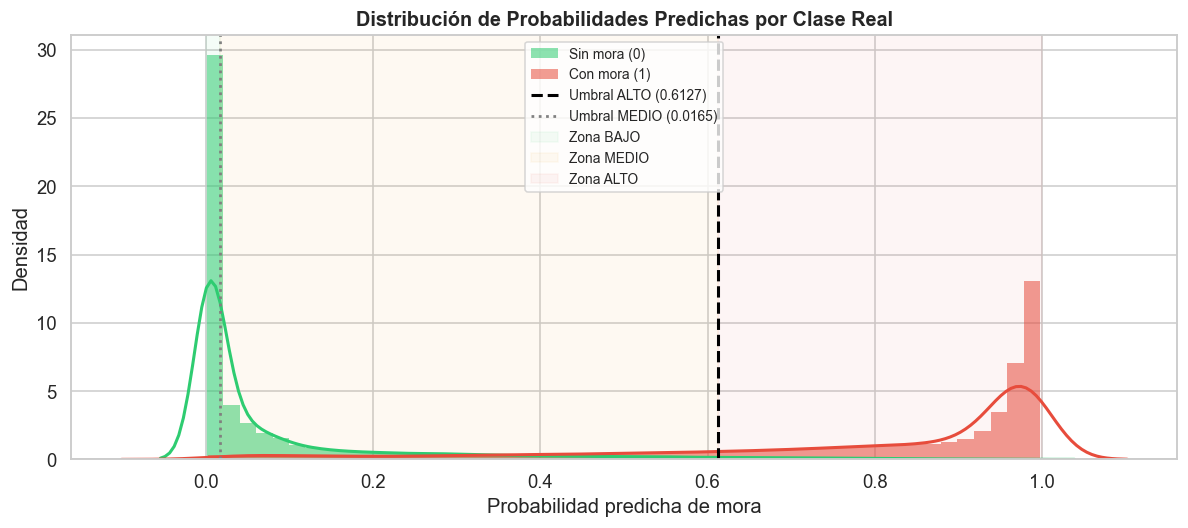

In [8]:
# Distribución de probabilidades predichas por clase
fig, ax = plt.subplots(figsize=(11, 5))

for val, color, label in [(0, VERDE, 'Sin mora (0)'), (1, ROJO, 'Con mora (1)')]:
    probs_clase = y_prob[y_test == val]
    ax.hist(probs_clase, bins=50, alpha=0.55, color=color, label=label,
            density=True, edgecolor='none')
    sns.kdeplot(probs_clase, ax=ax, color=color, linewidth=2)

ax.axvline(metricas['umbral_alerta_alta'], color='black', linestyle='--', linewidth=2,
           label=f'Umbral ALTO ({metricas["umbral_alerta_alta"]:.4f})')
ax.axvline(metricas['umbral_alerta_media'], color='gray', linestyle=':', linewidth=1.8,
           label=f'Umbral MEDIO ({metricas["umbral_alerta_media"]:.4f})')

# Regiones de alerta
ax.axvspan(0, metricas['umbral_alerta_media'],
           alpha=0.05, color=VERDE, label='Zona BAJO')
ax.axvspan(metricas['umbral_alerta_media'], metricas['umbral_alerta_alta'],
           alpha=0.05, color=AMARILLO, label='Zona MEDIO')
ax.axvspan(metricas['umbral_alerta_alta'], 1.0,
           alpha=0.05, color=ROJO, label='Zona ALTO')

ax.set_xlabel('Probabilidad predicha de mora')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Probabilidades Predichas por Clase Real', fontweight='bold')
ax.legend(loc='upper center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Importancia de Variables

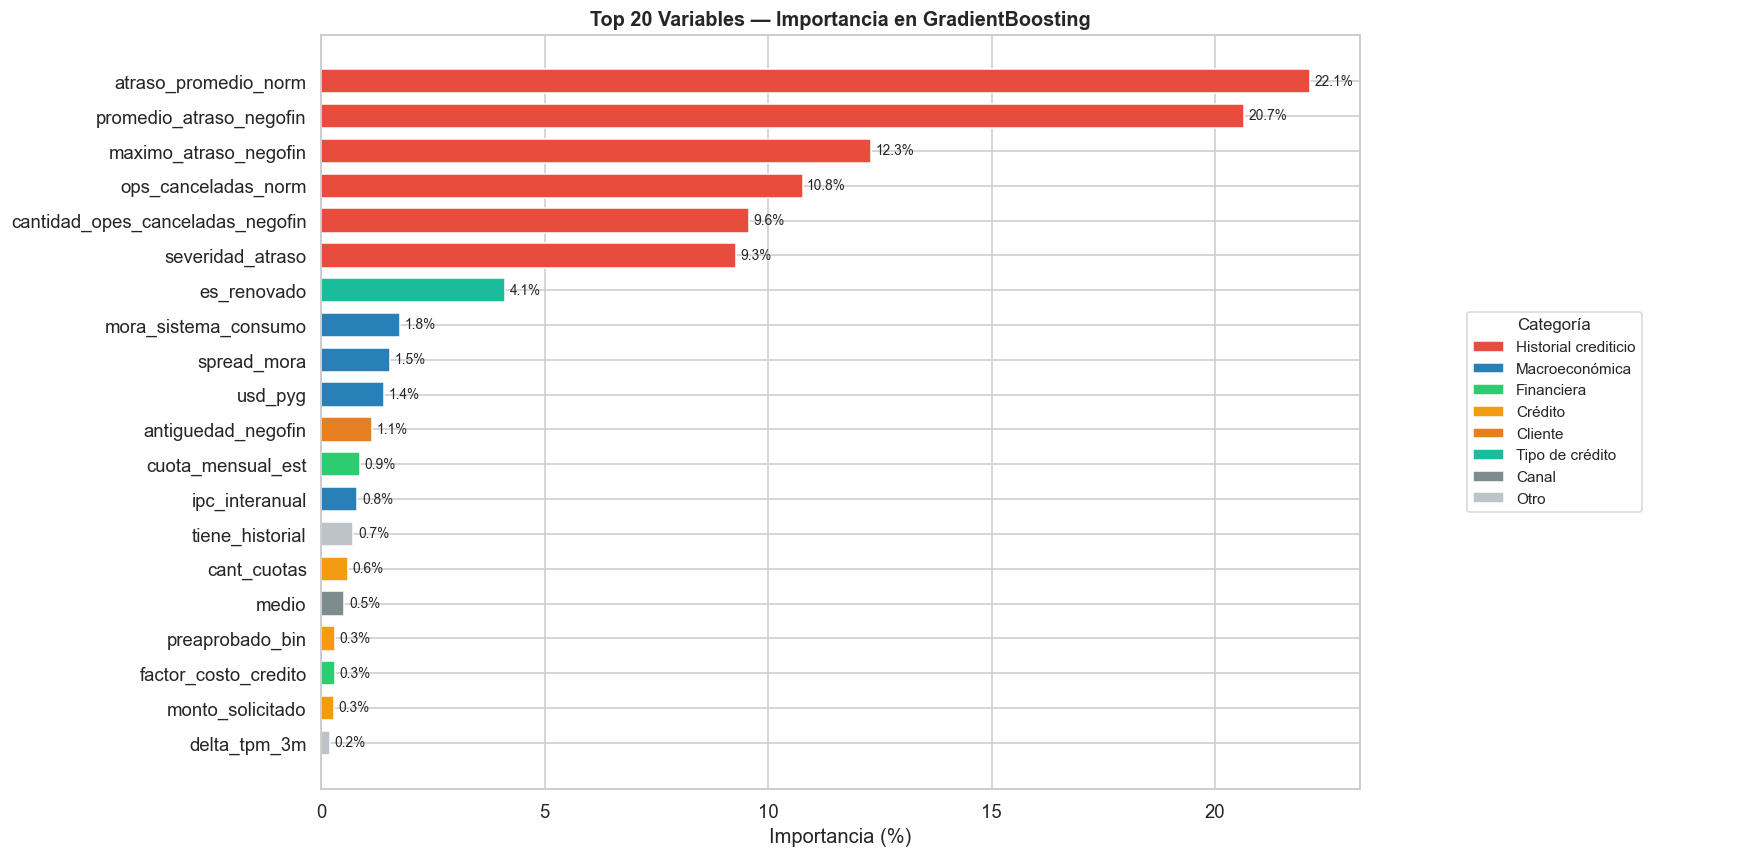

In [9]:
# Top 20 features
fi_top = fi_df.head(20).copy()
fi_top = fi_top.sort_values('importance_pct')

# Categorías de variables
cat_map = {
    'promedio_atraso_negofin':           'Historial crediticio',
    'atraso_promedio_norm':              'Historial crediticio',
    'maximo_atraso_negofin':             'Historial crediticio',
    'severidad_atraso':                  'Historial crediticio',
    'cantidad_opes_canceladas_negofin':  'Historial crediticio',
    'ops_canceladas_norm':               'Historial crediticio',
    'es_renovado':                       'Tipo de crédito',
    'usd_pyg':                           'Macroeconómica',
    'spread_mora':                       'Macroeconómica',
    'mora_sistema_consumo':              'Macroeconómica',
    'cuota_mensual_est':                 'Financiera',
    'cant_cuotas':                       'Crédito',
    'ratio_cuota_ingreso':               'Financiera',
    'antiguedad_negofin':                'Cliente',
    'medio':                             'Canal',
    'edad':                              'Demográfica',
    'monto_solicitado':                  'Crédito',
    'factor_costo_credito':              'Financiera',
    'preaprobado_bin':                   'Crédito',
    'ipc_interanual':                    'Macroeconómica',
}

fi_top['categoria'] = fi_top['feature'].map(cat_map).fillna('Otro')

palette_cat = {
    'Historial crediticio': ROJO,
    'Macroeconómica':       AZUL,
    'Financiera':           VERDE,
    'Crédito':              AMARILLO,
    'Demográfica':          MORADO,
    'Cliente':              '#E67E22',
    'Tipo de crédito':      '#1ABC9C',
    'Canal':                '#7F8C8D',
    'Otro':                 '#BDC3C7'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [3, 1]})

# Barplot horizontal
colores_fi = [palette_cat.get(c, '#BDC3C7') for c in fi_top['categoria']]
bars = axes[0].barh(fi_top['feature'], fi_top['importance_pct'],
                    color=colores_fi, edgecolor='white', height=0.7)

for bar, val in zip(bars, fi_top['importance_pct']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)

axes[0].set_xlabel('Importancia (%)')
axes[0].set_title('Top 20 Variables — Importancia en GradientBoosting', fontweight='bold')

# Leyenda de categorías
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette_cat.items()
                   if k in fi_top['categoria'].values]
axes[1].legend(handles=legend_elements, loc='center', frameon=True,
               title='Categoría', fontsize=10, title_fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()

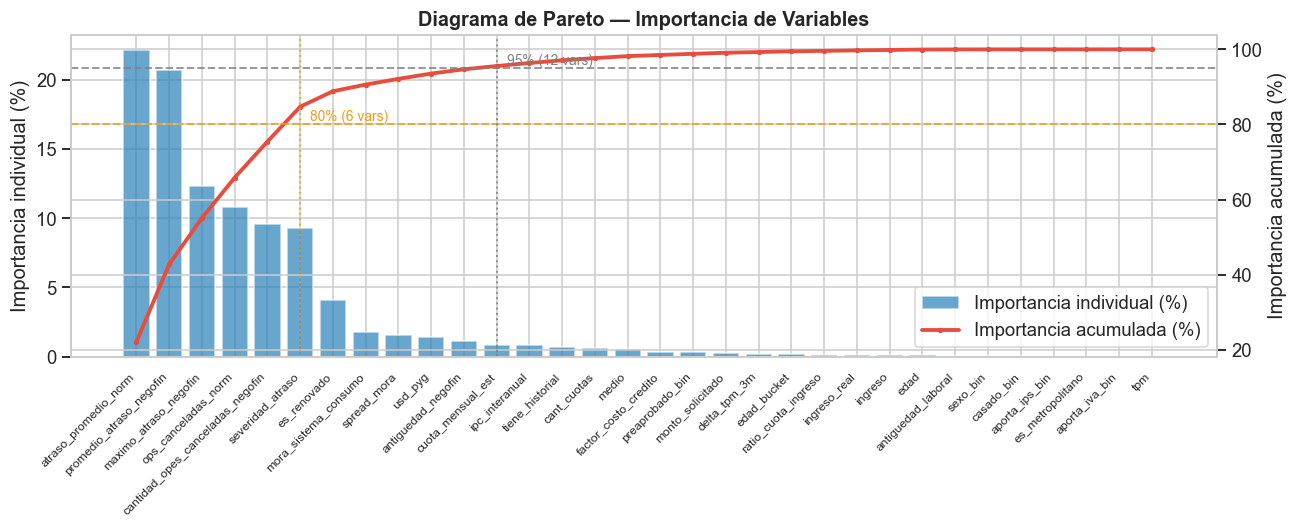

In [10]:
# Importancia acumulada — curva de Pareto
fi_sorted = fi_df.sort_values('importance_pct', ascending=False).reset_index(drop=True)
fi_sorted['importancia_acum'] = fi_sorted['importance_pct'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(range(len(fi_sorted)), fi_sorted['importance_pct'],
        color=AZUL, alpha=0.7, label='Importancia individual (%)')
ax2.plot(range(len(fi_sorted)), fi_sorted['importancia_acum'],
         color=ROJO, linewidth=2.5, marker='.', markersize=5, label='Importancia acumulada (%)')

# Líneas de referencia 80% y 95%
for nivel, color in [(80, AMARILLO), (95, 'gray')]:
    idx_nivel = (fi_sorted['importancia_acum'] >= nivel).idxmax()
    ax2.axhline(nivel, linestyle='--', color=color, linewidth=1.3, alpha=0.8)
    ax2.axvline(idx_nivel, linestyle=':', color=color, linewidth=1.3, alpha=0.8)
    ax2.text(idx_nivel + 0.3, nivel + 1, f'{nivel}% ({idx_nivel+1} vars)',
             color=color, fontsize=9)

ax1.set_xticks(range(len(fi_sorted)))
ax1.set_xticklabels(fi_sorted['feature'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Importancia individual (%)')
ax2.set_ylabel('Importancia acumulada (%)')
ax1.set_title('Diagrama de Pareto — Importancia de Variables', fontweight='bold')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='lower right')
plt.tight_layout()
plt.show()

---
## 6. Validación Cruzada

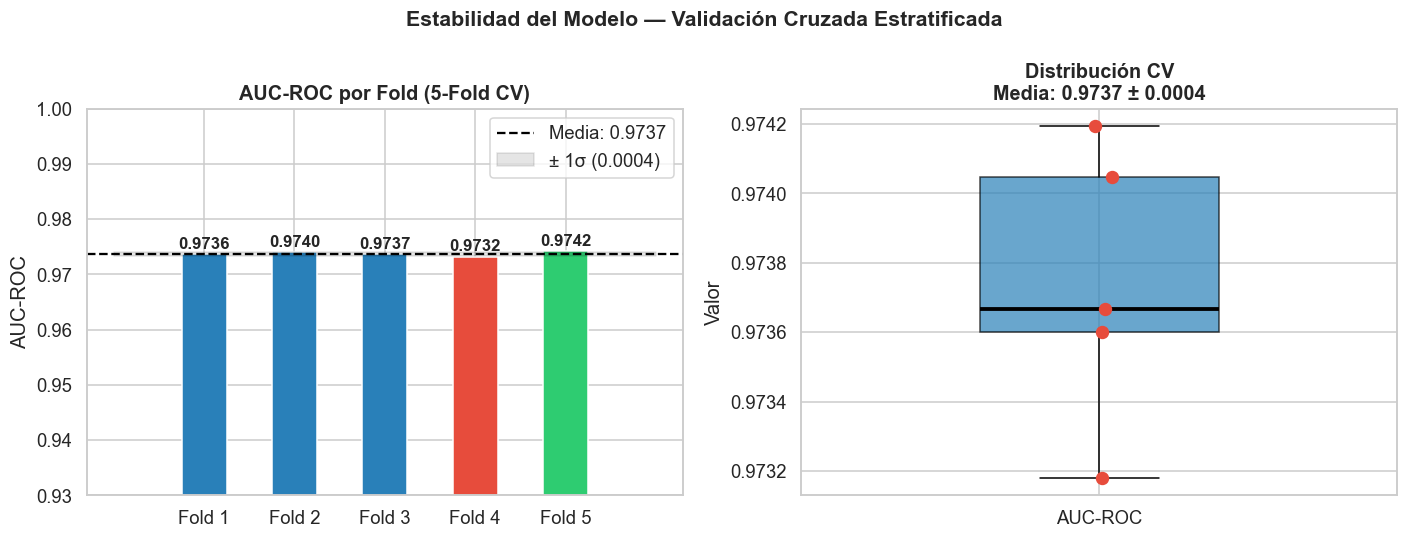

In [11]:
# CV 5-fold — AUC por fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras por fold
folds = [f'Fold {i+1}' for i in range(5)]
bar_colors = [ROJO if s < cv_scores.mean() - cv_scores.std() else
              VERDE if s > cv_scores.mean() + cv_scores.std() else AZUL
              for s in cv_scores]
bars = axes[0].bar(folds, cv_scores, color=bar_colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, cv_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

axes[0].axhline(cv_scores.mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Media: {cv_scores.mean():.4f}')
axes[0].fill_between(range(-1, 6),
                     cv_scores.mean() - cv_scores.std(),
                     cv_scores.mean() + cv_scores.std(),
                     alpha=0.1, color='black', label=f'± 1σ ({cv_scores.std():.4f})')
axes[0].set_ylim([0.93, 1.0])
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC-ROC por Fold (5-Fold CV)', fontweight='bold')
axes[0].legend()

# Boxplot de scores
bp = axes[1].boxplot(cv_scores, patch_artist=True, widths=0.4,
                     medianprops={'color': 'black', 'linewidth': 2.5},
                     flierprops={'marker': 'o', 'markerfacecolor': ROJO})
bp['boxes'][0].set_facecolor(AZUL)
bp['boxes'][0].set_alpha(0.7)

# Puntos individuales
jitter = np.random.RandomState(0).uniform(-0.05, 0.05, len(cv_scores))
axes[1].scatter(1 + jitter, cv_scores, color=ROJO, s=60, zorder=5)

axes[1].set_xticks([1])
axes[1].set_xticklabels(['AUC-ROC'])
axes[1].set_ylabel('Valor')
axes[1].set_title(f'Distribución CV\nMedia: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}',
                  fontweight='bold')

plt.suptitle('Estabilidad del Modelo — Validación Cruzada Estratificada',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Calibración del Modelo

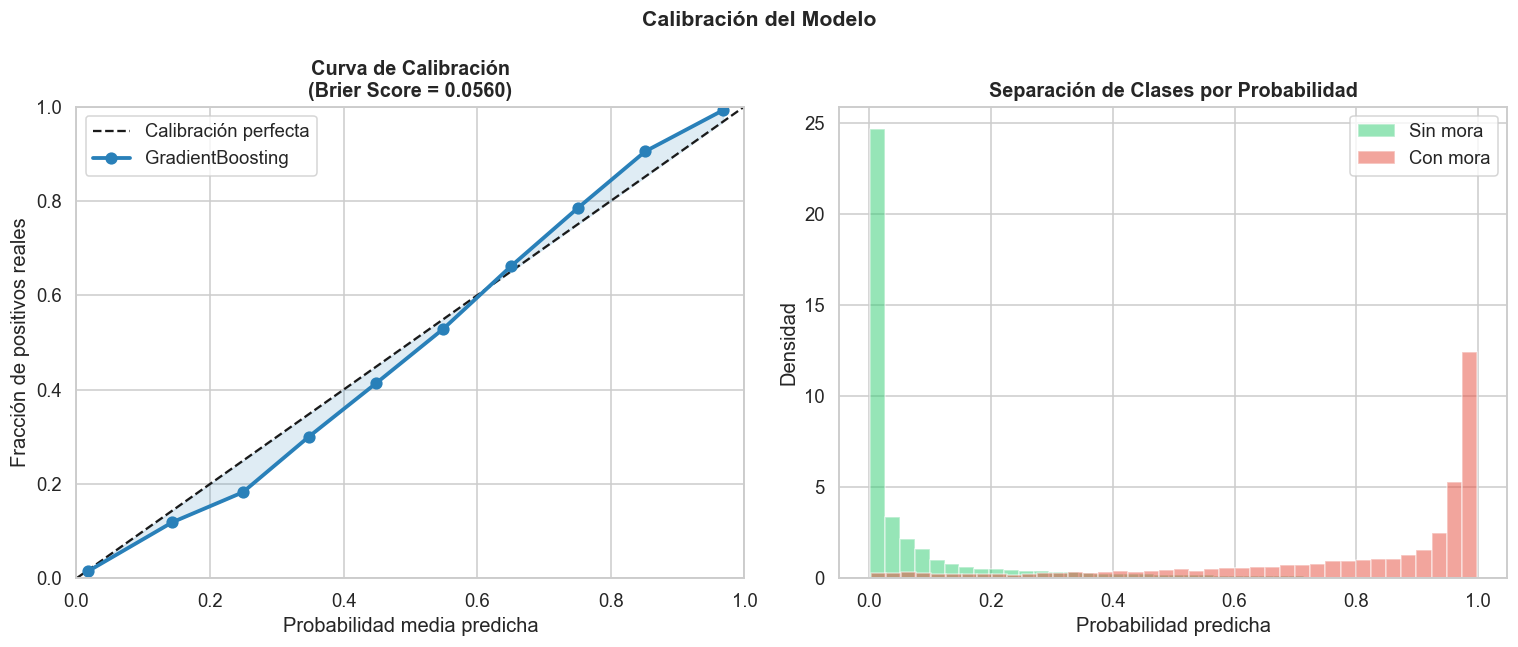

In [12]:
# Curva de calibración + histograma de probabilidades
prob_true, prob_pred_cal = calibration_curve(y_test, y_prob, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calibration curve
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Calibración perfecta')
axes[0].plot(prob_pred_cal, prob_true, color=AZUL, linewidth=2.5,
             marker='o', markersize=7, label='GradientBoosting')
axes[0].fill_between(prob_pred_cal, prob_true, prob_pred_cal,
                     alpha=0.15, color=AZUL)
axes[0].set_xlabel('Probabilidad media predicha')
axes[0].set_ylabel('Fracción de positivos reales')
axes[0].set_title(f'Curva de Calibración\n(Brier Score = {brier_score_loss(y_test, y_prob):.4f})',
                  fontweight='bold')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Histograma de probabilidades por clase
axes[1].hist(y_prob[y_test == 0], bins=40, alpha=0.5, color=VERDE,
             label='Sin mora', density=True)
axes[1].hist(y_prob[y_test == 1], bins=40, alpha=0.5, color=ROJO,
             label='Con mora', density=True)
axes[1].set_xlabel('Probabilidad predicha')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Separación de Clases por Probabilidad', fontweight='bold')
axes[1].legend()

plt.suptitle('Calibración del Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Distribución y Eficacia de las Alertas

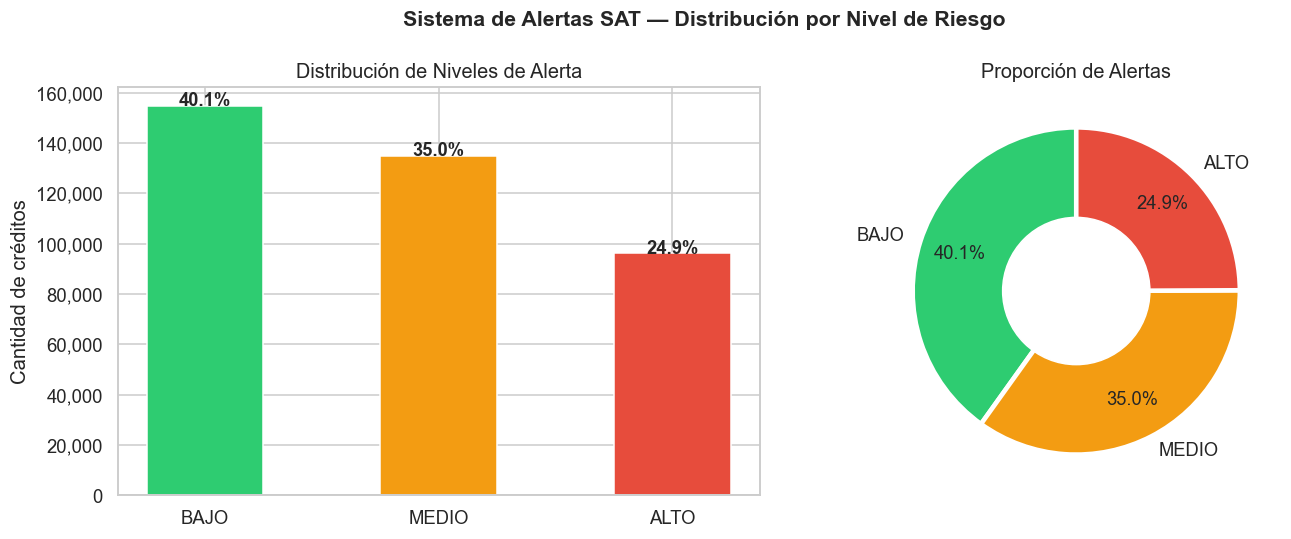

In [13]:
# Distribución de niveles de alerta
nivel_counts = alertas['nivel_alerta'].value_counts()
orden_niveles = ['BAJO', 'MEDIO', 'ALTO']
colores_alerta = {'BAJO': VERDE, 'MEDIO': AMARILLO, 'ALTO': ROJO}

nivel_counts = nivel_counts.reindex(orden_niveles)
nivel_pct = nivel_counts / nivel_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
bars = axes[0].bar(
    nivel_counts.index,
    nivel_counts.values,
    color=[colores_alerta[n] for n in nivel_counts.index],
    width=0.5, edgecolor='white'
)
for bar, pct in zip(bars, nivel_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Cantidad de créditos')
axes[0].set_title('Distribución de Niveles de Alerta')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Donut
wedge_props = {'linewidth': 3, 'edgecolor': 'white'}
axes[1].pie(
    nivel_counts.values,
    labels=nivel_counts.index,
    colors=[colores_alerta[n] for n in nivel_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=wedge_props,
    pctdistance=0.75,
    textprops={'fontsize': 12}
)
# Círculo central para efecto donut
centre_circle = plt.Circle((0, 0), 0.45, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Proporción de Alertas')

plt.suptitle('Sistema de Alertas SAT — Distribución por Nivel de Riesgo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

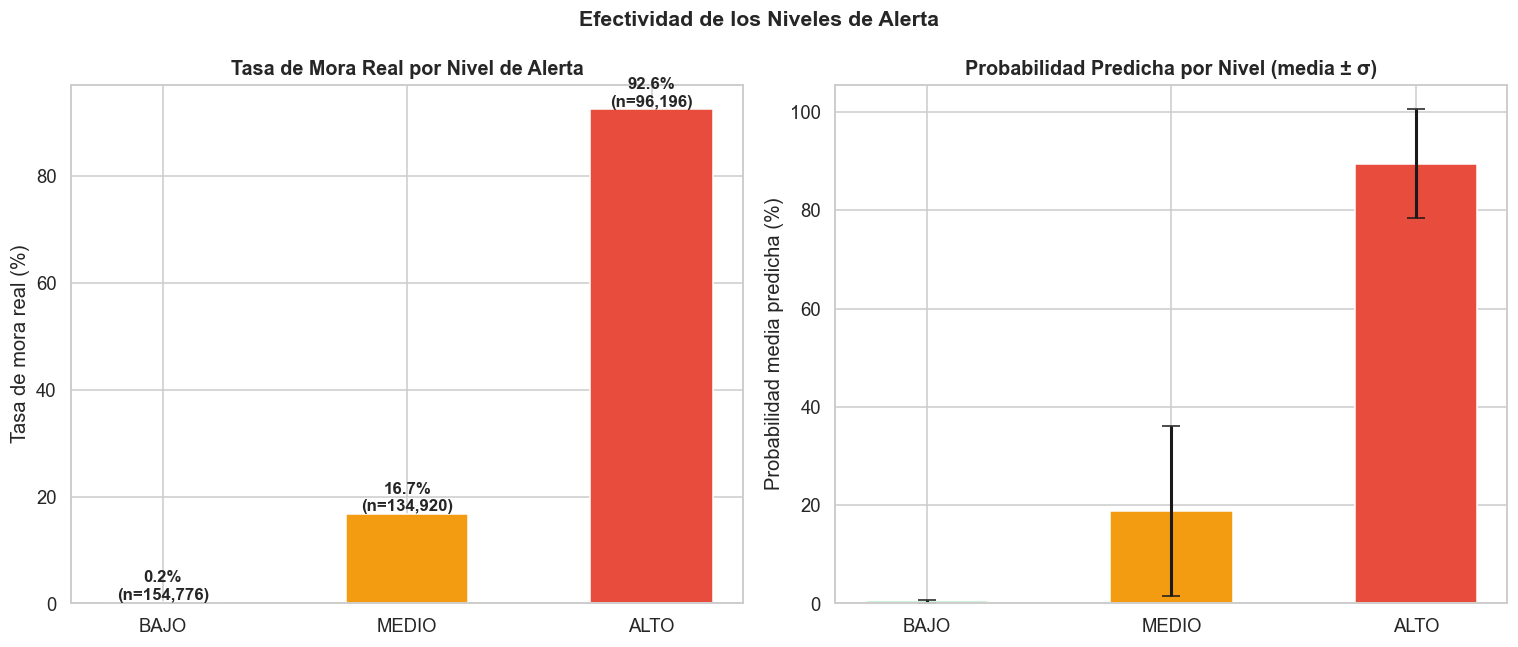

In [14]:
# Tasa de mora real por nivel de alerta
mora_por_nivel = alertas.groupby('nivel_alerta')['atraso_30'].agg(['mean', 'count']).reset_index()
mora_por_nivel['mean'] *= 100
mora_por_nivel = mora_por_nivel.set_index('nivel_alerta').reindex(orden_niveles).reset_index()

# Probabilidad promedio predicha por nivel
prob_por_nivel = alertas.groupby('nivel_alerta')['prob_mora_30'].agg(['mean', 'std']).reset_index()
prob_por_nivel = prob_por_nivel.set_index('nivel_alerta').reindex(orden_niveles).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tasa real de mora por nivel
bars = axes[0].bar(
    mora_por_nivel['nivel_alerta'],
    mora_por_nivel['mean'],
    color=[colores_alerta[n] for n in mora_por_nivel['nivel_alerta']],
    width=0.5, edgecolor='white'
)
for bar, val, cnt in zip(bars, mora_por_nivel['mean'], mora_por_nivel['count']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%\n(n={cnt:,})', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Tasa de mora real (%)')
axes[0].set_title('Tasa de Mora Real por Nivel de Alerta', fontweight='bold')

# Probabilidad predicha por nivel (media ± std)
x_pos = range(len(orden_niveles))
axes[1].bar(
    x_pos,
    prob_por_nivel['mean'] * 100,
    yerr=prob_por_nivel['std'] * 100,
    color=[colores_alerta[n] for n in orden_niveles],
    width=0.5, edgecolor='white',
    capsize=6, error_kw={'linewidth': 2}
)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(orden_niveles)
axes[1].set_ylabel('Probabilidad media predicha (%)')
axes[1].set_title('Probabilidad Predicha por Nivel (media ± σ)', fontweight='bold')

plt.suptitle('Efectividad de los Niveles de Alerta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

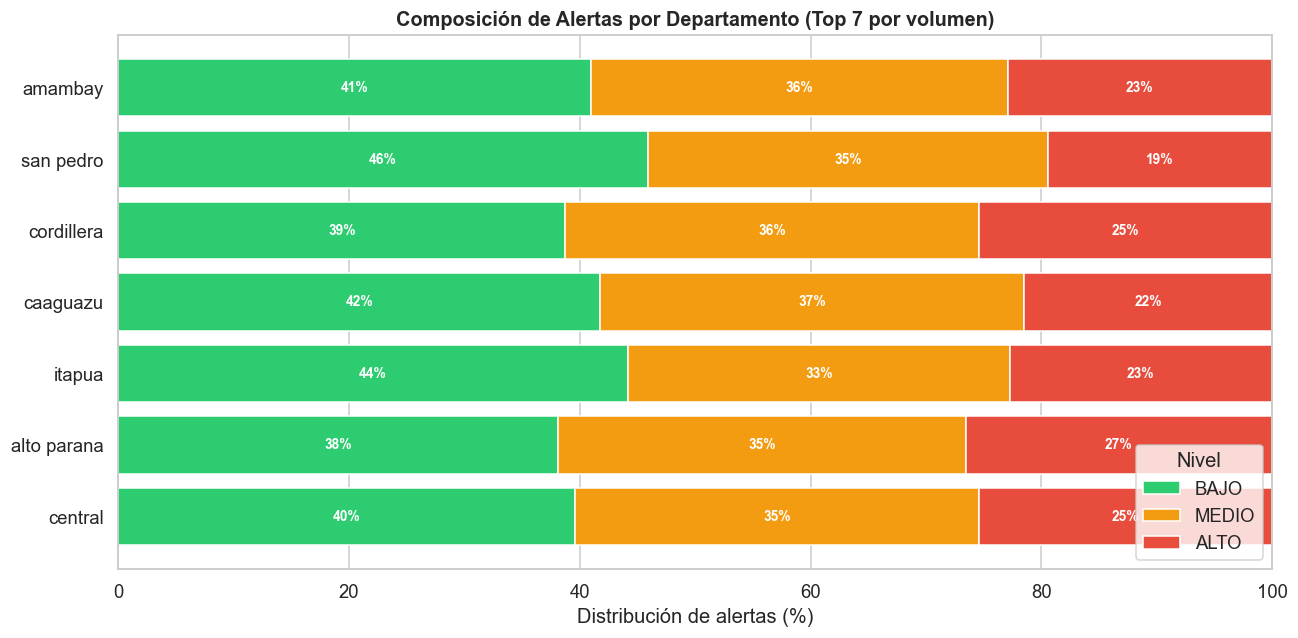

In [15]:
# Distribución de alertas por departamento — Top 5
dept_nivel = alertas.groupby(['nombre_departamento_particular', 'nivel_alerta']).size().unstack(fill_value=0)
dept_nivel = dept_nivel.reindex(columns=orden_niveles, fill_value=0)
dept_nivel = dept_nivel.loc[dept_nivel.sum(axis=1).nlargest(7).index]
dept_nivel_pct = dept_nivel.div(dept_nivel.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(dept_nivel_pct))
for nivel, color in [('BAJO', VERDE), ('MEDIO', AMARILLO), ('ALTO', ROJO)]:
    if nivel in dept_nivel_pct.columns:
        vals = dept_nivel_pct[nivel].values
        ax.barh(dept_nivel_pct.index, vals, left=bottom,
                color=color, label=nivel, edgecolor='white')
        # Etiquetas solo si son > 8%
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 8:
                ax.text(b + v / 2, i, f'{v:.0f}%',
                        ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += vals

ax.set_xlabel('Distribución de alertas (%)')
ax.set_title('Composición de Alertas por Departamento (Top 7 por volumen)', fontweight='bold')
ax.legend(title='Nivel', loc='lower right')
ax.set_xlim([0, 100])
plt.tight_layout()
plt.show()

---
## 9. Comparación Train vs Test — Sobreajuste

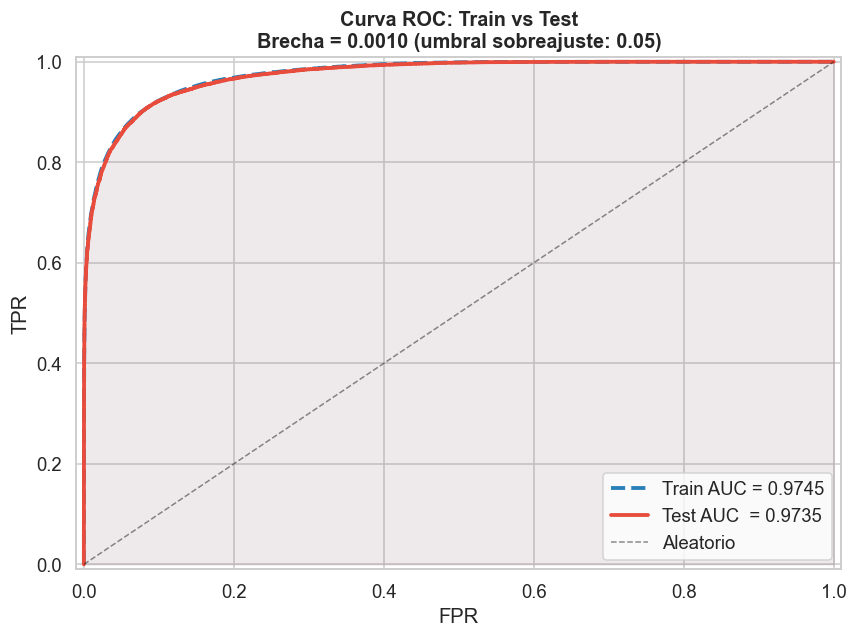

Brecha AUC (train - test): 0.0010  →  SIN sobreajuste significativo


In [16]:
# Curvas ROC train vs test
y_prob_train = pipeline.predict_proba(X_train)[:, 1]
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_prob_train)
auc_tr = auc(fpr_tr, tpr_tr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_tr, tpr_tr, color=AZUL,   linewidth=2.5, label=f'Train AUC = {auc_tr:.4f}', linestyle='--')
ax.plot(fpr, tpr,       color=ROJO,   linewidth=2.5, label=f'Test AUC  = {roc_auc_calc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')

ax.fill_between(fpr_tr, tpr_tr, alpha=0.07, color=AZUL)
ax.fill_between(fpr, tpr, alpha=0.07, color=ROJO)

brecha = auc_tr - roc_auc_calc
ax.set_title(f'Curva ROC: Train vs Test\nBrecha = {brecha:.4f} (umbral sobreajuste: 0.05)',
             fontweight='bold')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f'Brecha AUC (train - test): {brecha:.4f}  →  {"SIN sobreajuste significativo" if brecha < 0.05 else "POSIBLE sobreajuste"}')

---
## 10. Reporte Final de Clasificación

In [17]:
report = classification_report(y_test, y_pred,
                                target_names=['Sin mora (0)', 'Con mora (1)'],
                                output_dict=True)
report_df = pd.DataFrame(report).T
report_df.index.name = 'Clase'
report_df = report_df.drop(columns=['support'], errors='ignore')

display(
    report_df.style
    .format('{:.4f}', subset=['precision', 'recall', 'f1-score'])
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1,
                         subset=['precision', 'recall', 'f1-score'])
    .set_caption(f'Reporte completo — Umbral: {umbral_f1:.4f}')
)

,precision,recall,f1-score
Clase,,,
Sin mora (0),0.9457,0.9454,0.9456
Con mora (1),0.8667,0.8673,0.8670
accuracy,0.9228,0.9228,0.9228
macro avg,0.9062,0.9064,0.9063
weighted avg,0.9228,0.9228,0.9228


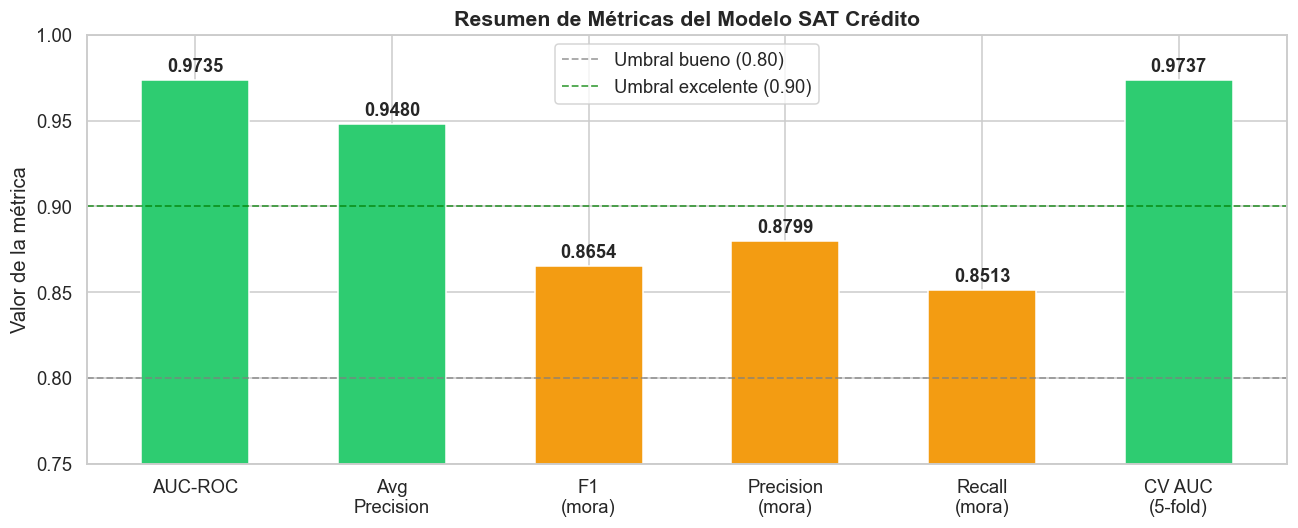


=== CONCLUSIÓN ===
  AUC-ROC Test:    0.9735  → Discriminación excelente
  F1 clase mora:   0.8654  → Balance precision/recall muy bueno
  CV AUC (5-fold): 0.9737 ± 0.0003  → Modelo estable
  Brecha overfitting: 0.0010  → Sin sobreajuste significativo


In [18]:
# Resumen visual final de métricas
metricas_finales = {
    'AUC-ROC': metricas['auc_roc_test'],
    'Avg\nPrecision': metricas['avg_precision'],
    'F1\n(mora)': metricas['f1_class1'],
    'Precision\n(mora)': metricas['precision_class1'],
    'Recall\n(mora)': metricas['recall_class1'],
    'CV AUC\n(5-fold)': metricas['cv_auc_mean']
}

fig, ax = plt.subplots(figsize=(12, 5))
nombres = list(metricas_finales.keys())
valores = list(metricas_finales.values())

bar_cols = [ROJO if v < 0.80 else AMARILLO if v < 0.90 else VERDE for v in valores]
bars = ax.bar(nombres, valores, color=bar_cols, width=0.55, edgecolor='white')

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

ax.axhline(0.80, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Umbral bueno (0.80)')
ax.axhline(0.90, color='green', linestyle='--', linewidth=1.2, alpha=0.7, label='Umbral excelente (0.90)')
ax.set_ylim([0.75, 1.0])
ax.set_ylabel('Valor de la métrica')
ax.set_title('Resumen de Métricas del Modelo SAT Crédito', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== CONCLUSIÓN ===')
print(f'  AUC-ROC Test:    {metricas["auc_roc_test"]:.4f}  → Discriminación excelente')
print(f'  F1 clase mora:   {metricas["f1_class1"]:.4f}  → Balance precision/recall muy bueno')
print(f'  CV AUC (5-fold): {metricas["cv_auc_mean"]:.4f} ± {metricas["cv_auc_std"]:.4f}  → Modelo estable')
print(f'  Brecha overfitting: {metricas["overfit_gap"]:.4f}  → Sin sobreajuste significativo')